In [35]:
import sys
print(sys.executable)

c:\Users\mraic\.pyenv\pyenv-win\versions\3.12.7\python.exe


In [1]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

## Upload data

In [ ]:
!pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
default_of_credit_card_clients = fetch_ucirepo(id=350)

# data (as pandas dataframes)
X = default_of_credit_card_clients.data.features
y = default_of_credit_card_clients.data.targets

# metadata
print(default_of_credit_card_clients.metadata)

# variable information
print(default_of_credit_card_clients.variables)


{'uci_id': 350, 'name': 'Default of Credit Card Clients', 'repository_url': 'https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients', 'data_url': 'https://archive.ics.uci.edu/static/public/350/data.csv', 'abstract': "This research aimed at the case of customers' default payments in Taiwan and compares the predictive accuracy of probability of default among six data mining methods.", 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 30000, 'num_features': 23, 'feature_types': ['Integer', 'Real'], 'demographics': ['Sex', 'Education Level', 'Marital Status', 'Age'], 'target_col': ['Y'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Fri Mar 29 2024', 'dataset_doi': '10.24432/C55S3H', 'creators': ['I-Cheng Yeh'], 'intro_paper': {'ID': 365, 'type': 'NATIVE', 'title': 'The comparisons of data mining techniques for the predictive accuracy of 

Renaming the column names

In [3]:
column_mapping = {
    str(default_of_credit_card_clients.variables.name[i]): str(default_of_credit_card_clients.variables.description[i])
    for i in range(1, len(default_of_credit_card_clients.variables))
}
X = X.rename(columns=column_mapping)

# Rename PAY_0 -> PAY_1
X = X.rename(columns={'PAY_0': 'PAY_1'})

# Rename Y-> default.payment.next.month
y = y.rename(columns={'Y': 'default.payment.next.month'})

X.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679


## Data Cleaning & Analysis
- Explore and clean the dataset
- Handle missing or inconsistent values
- Visualize key relationships



In [4]:
# defining numeric and categorical columns:

numeric_cols = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4',
'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

categorical_cols = ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

### Columns description:

- SEX: Gender (1=male, 2=female)
- EDUCATION: (1=graduate school, 2=university, 3=high school, 4=others, 5=unknown, 6=unknown)
- MARRIAGE: Marital status (1=married, 2=single, 3=others)
- PAY_1: Repayment status in September, 2005 (-1=pay duly, 1=payment delay for one month, 2=payment delay for two months, … 8=payment delay for eight months, 9=payment delay for nine months and above)
- PAY_2: Repayment status in August, 2005 (scale same as above)
- PAY_3: Repayment status in July, 2005 (scale same as above)
- PAY_4: Repayment status in June, 2005 (scale same as above)
- PAY_5: Repayment status in May, 2005 (scale same as above)
- PAY_6: Repayment status in April, 2005 (scale same as above)

Plot the distributions for numerical features:
['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2' 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

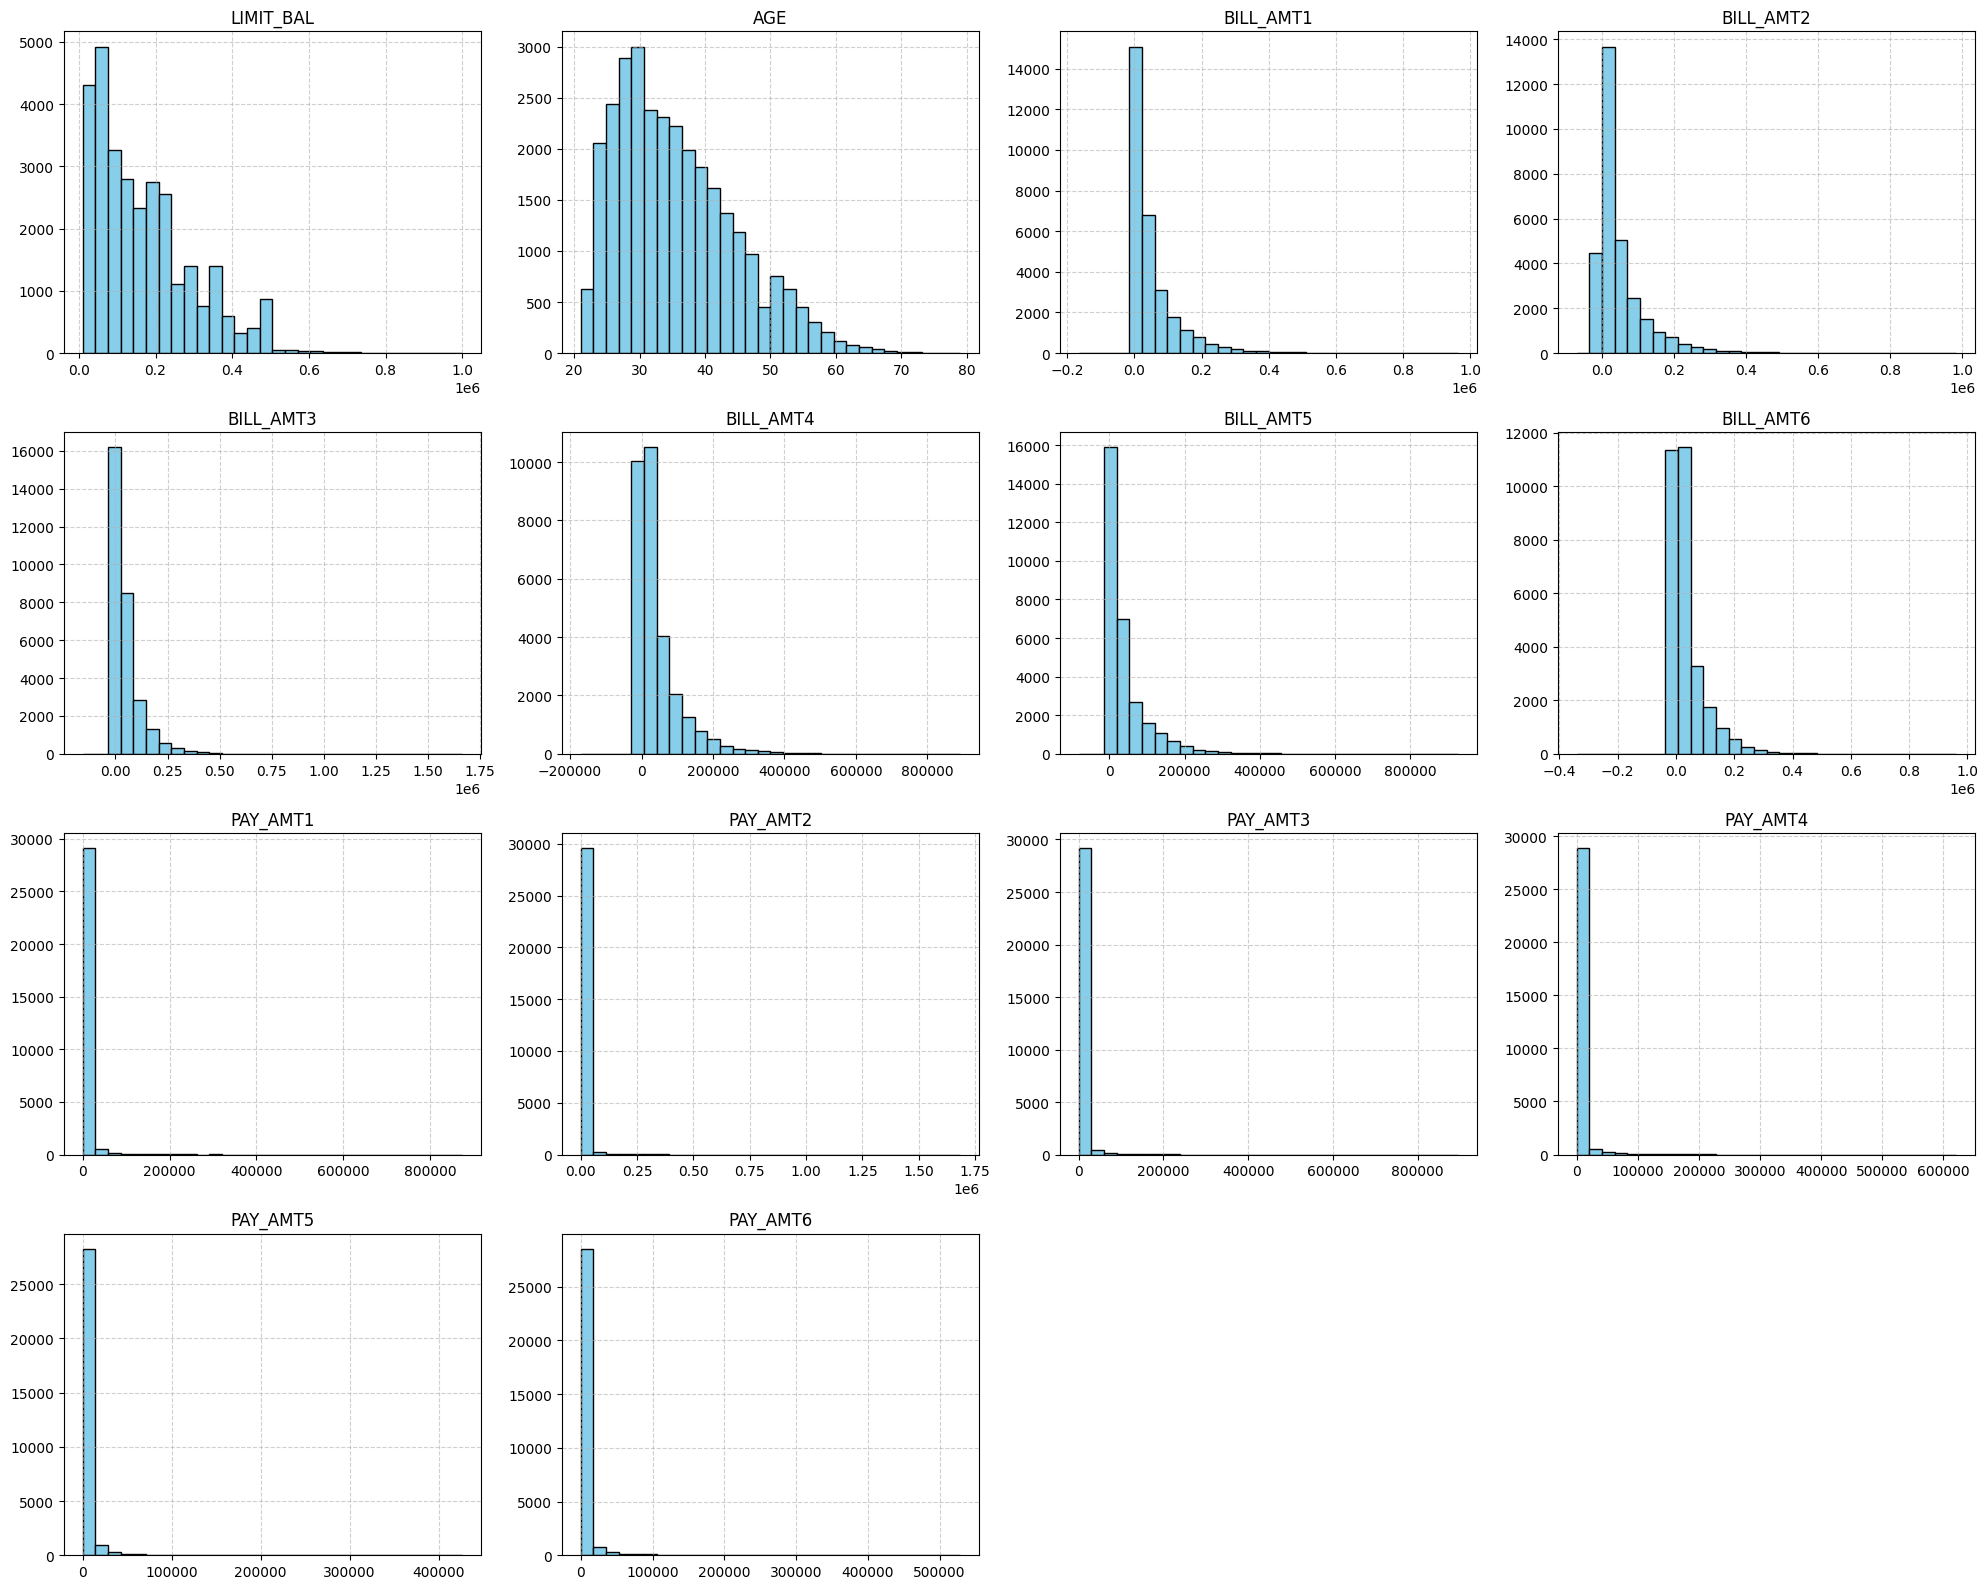

In [5]:
def plot_all_histograms(df, bins=20, columns_per_row=4, figsize=(20, 4)):
    """
    Plots histograms for all numeric columns in the given DataFrame.
    """
    n_cols = columns_per_row
    n_rows = math.ceil(len(numeric_cols) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(figsize[0], figsize[1] * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(numeric_cols):
        axes[i].hist(df[col].dropna(), bins=bins, color='skyblue', edgecolor='black')
        axes[i].set_title(col)
        axes[i].grid(True, linestyle='--', alpha=0.6)

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

plot_all_histograms(X, bins=30, columns_per_row=4)


The distributions for numeric features indicate that:

- The data requires standardization due to the presence of a log-normal distribution, which deviates from a normal distribution and may impact the assumptions of certain algorithms


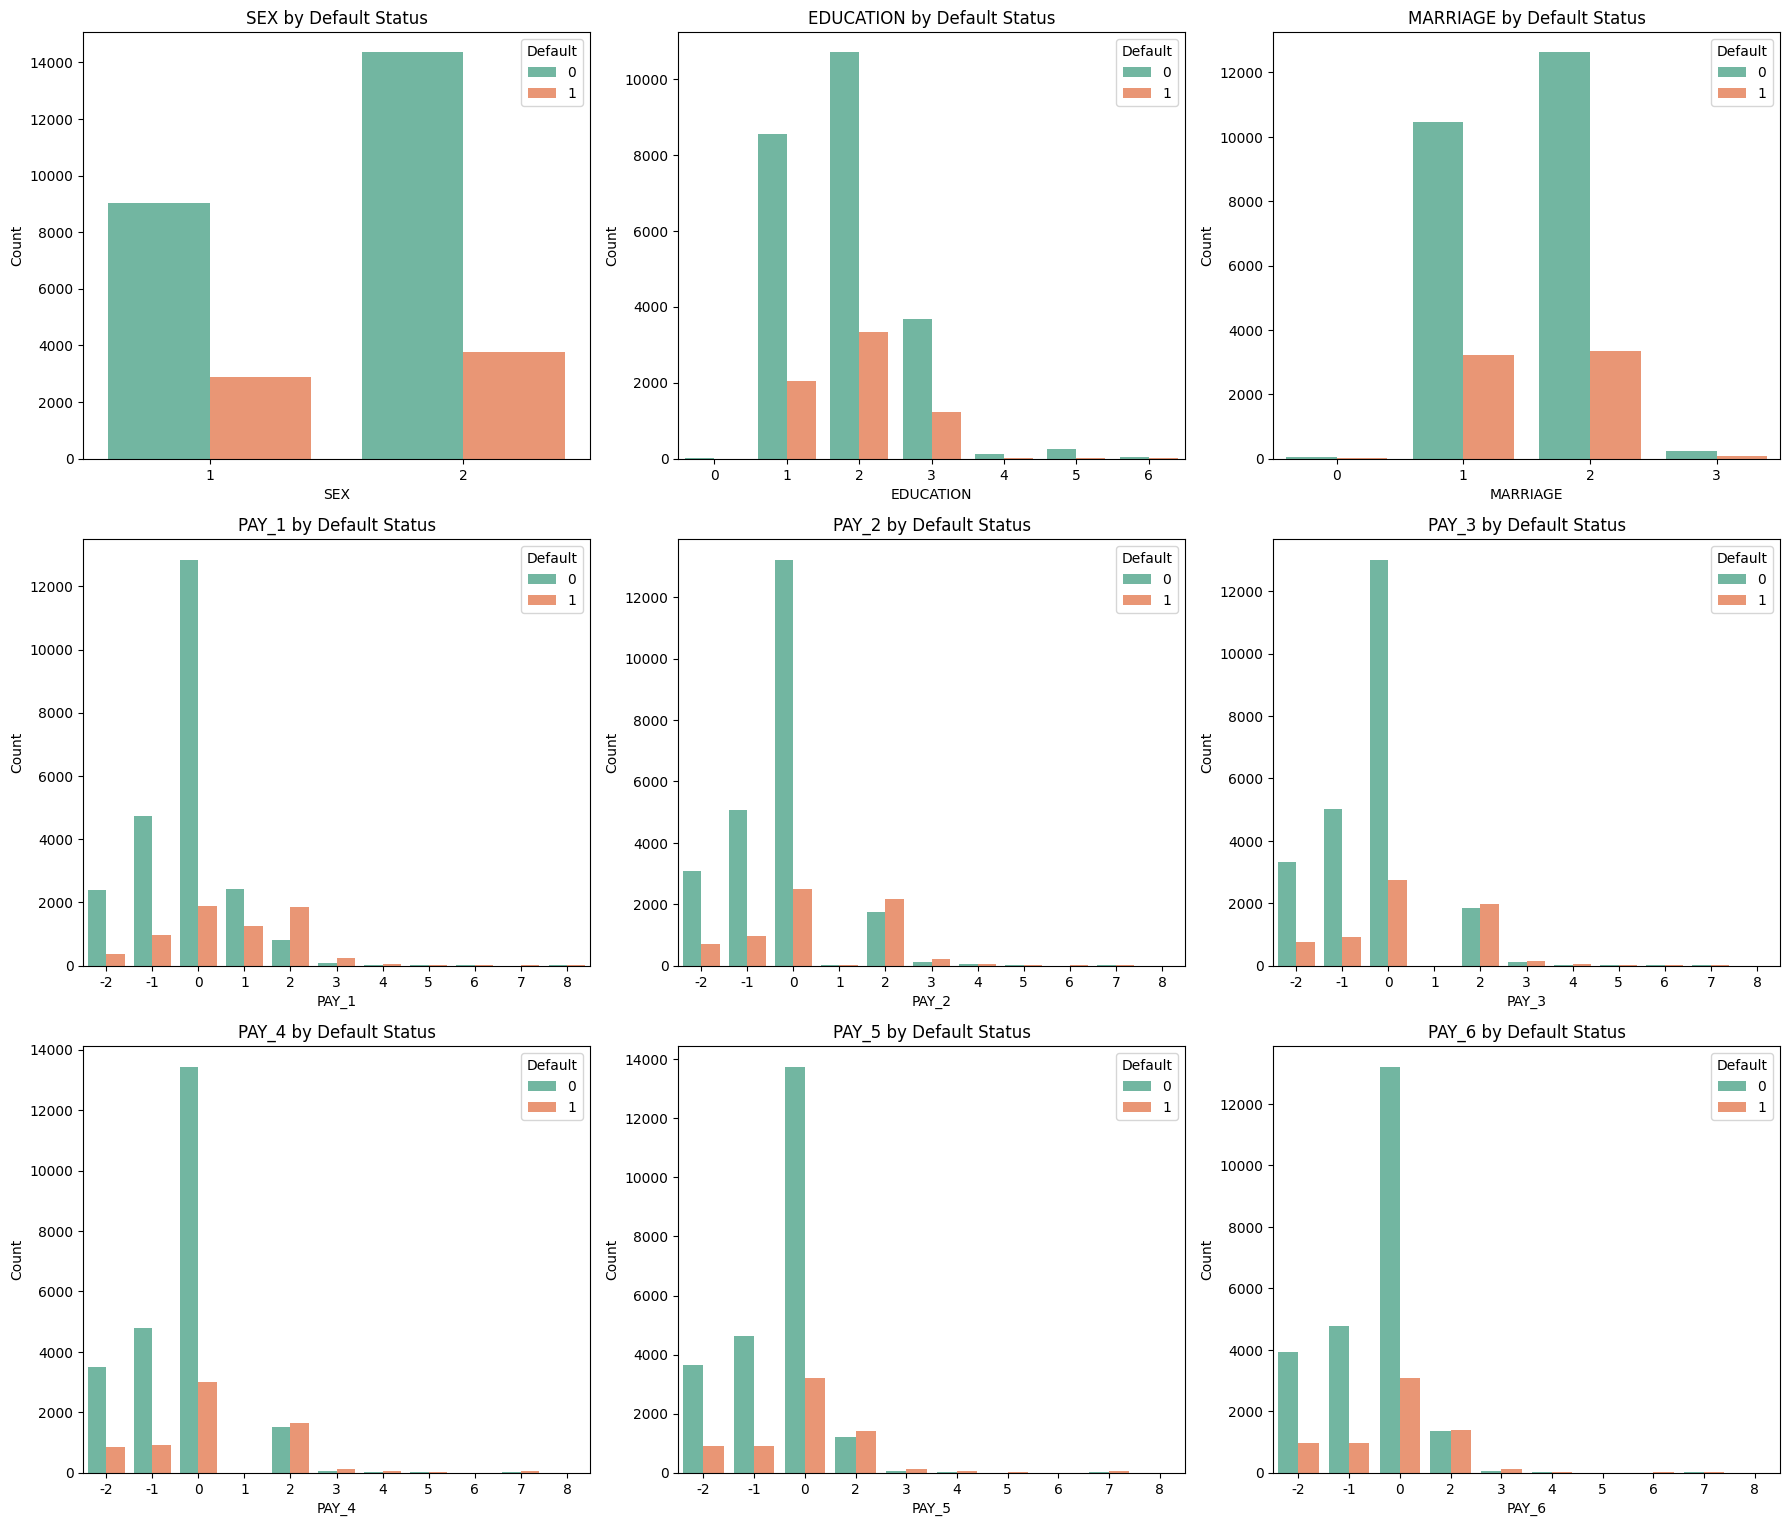

In [6]:
# visualization for categorical features

Xy = pd.concat([X, y], axis=1)

target_col = 'default.payment.next.month'

plt.figure(figsize=(18, 20))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(4, 3, i)
    sns.countplot(data=Xy, x=col, hue=target_col, palette='Set2', order=sorted(Xy[col].dropna().unique()))
    plt.title(f'{col} by Default Status')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.legend(title='Default')

plt.tight_layout()
plt.show()

- SEX: Gender (1=male, 2=female)
- EDUCATION: (1=graduate school, 2=university, 3=high school, 4=others, 5=unknown, 6=unknown)
- MARRIAGE: Marital status (1=married, 2=single, 3=others)
- PAY_1: Repayment status in September, 2005 (-1=pay duly, 1=payment delay for one month, 2=payment delay for two months, … 8=payment delay for eight months, 9=payment delay for nine months and above)
- PAY_2: Repayment status in August, 2005 (scale same as above)
- PAY_3: Repayment status in July, 2005 (scale same as above)
- PAY_4: Repayment status in June, 2005 (scale same as above)
- PAY_5: Repayment status in May, 2005 (scale same as above)
- PAY_6: Repayment status in April, 2005 (scale same as above)

The distributions for categorical features indicate that:

- While there are no NaN values, there are entries with zero values that may need attention, they will be replaced with the unknown label
- PAY_0 has negative values, it will be rescaled
- PAY_0 has -2 value that is not a category - it will be treated as unknown

Plot the default.payment.next.month to see if there is any data imbalanced

C:\Users\mraic\AppData\Local\Temp\ipykernel_16196\824655404.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='default.payment.next.month', data=y, palette='pastel')


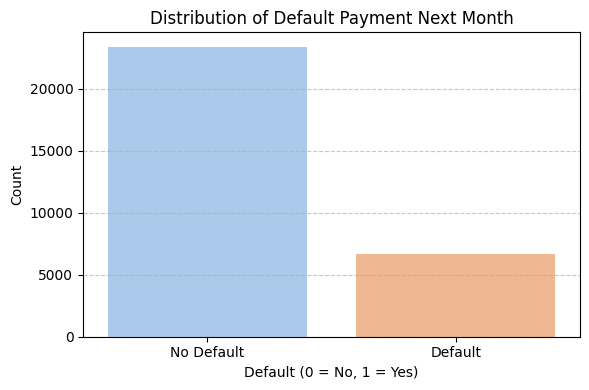

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(x='default.payment.next.month', data=y, palette='pastel')

plt.title('Distribution of Default Payment Next Month')
plt.xlabel('Default (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Default', 'Default'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

The histogram clearly shows: "No Default" (0) has significantly more samples than "Default" (1)

Resolving previous observations

In [8]:
X["MARRIAGE"].value_counts()

MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64

In [9]:
X["EDUCATION"].value_counts()

EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64

In [10]:
# 1. Replace 0 values with the special column unknown
X['MARRIAGE'] = X['MARRIAGE'].replace(0, 3)
X['EDUCATION'] = X['EDUCATION'].replace(0, 5)

In [11]:
# 2. Standardization of PAY_I
# -1 -> 0
# -2 -> -1

pay_columns = [col for col in X.columns if col.startswith('PAY_')]

X[pay_columns] = X[pay_columns].replace({
    -1: 0,
    -2: -1
})

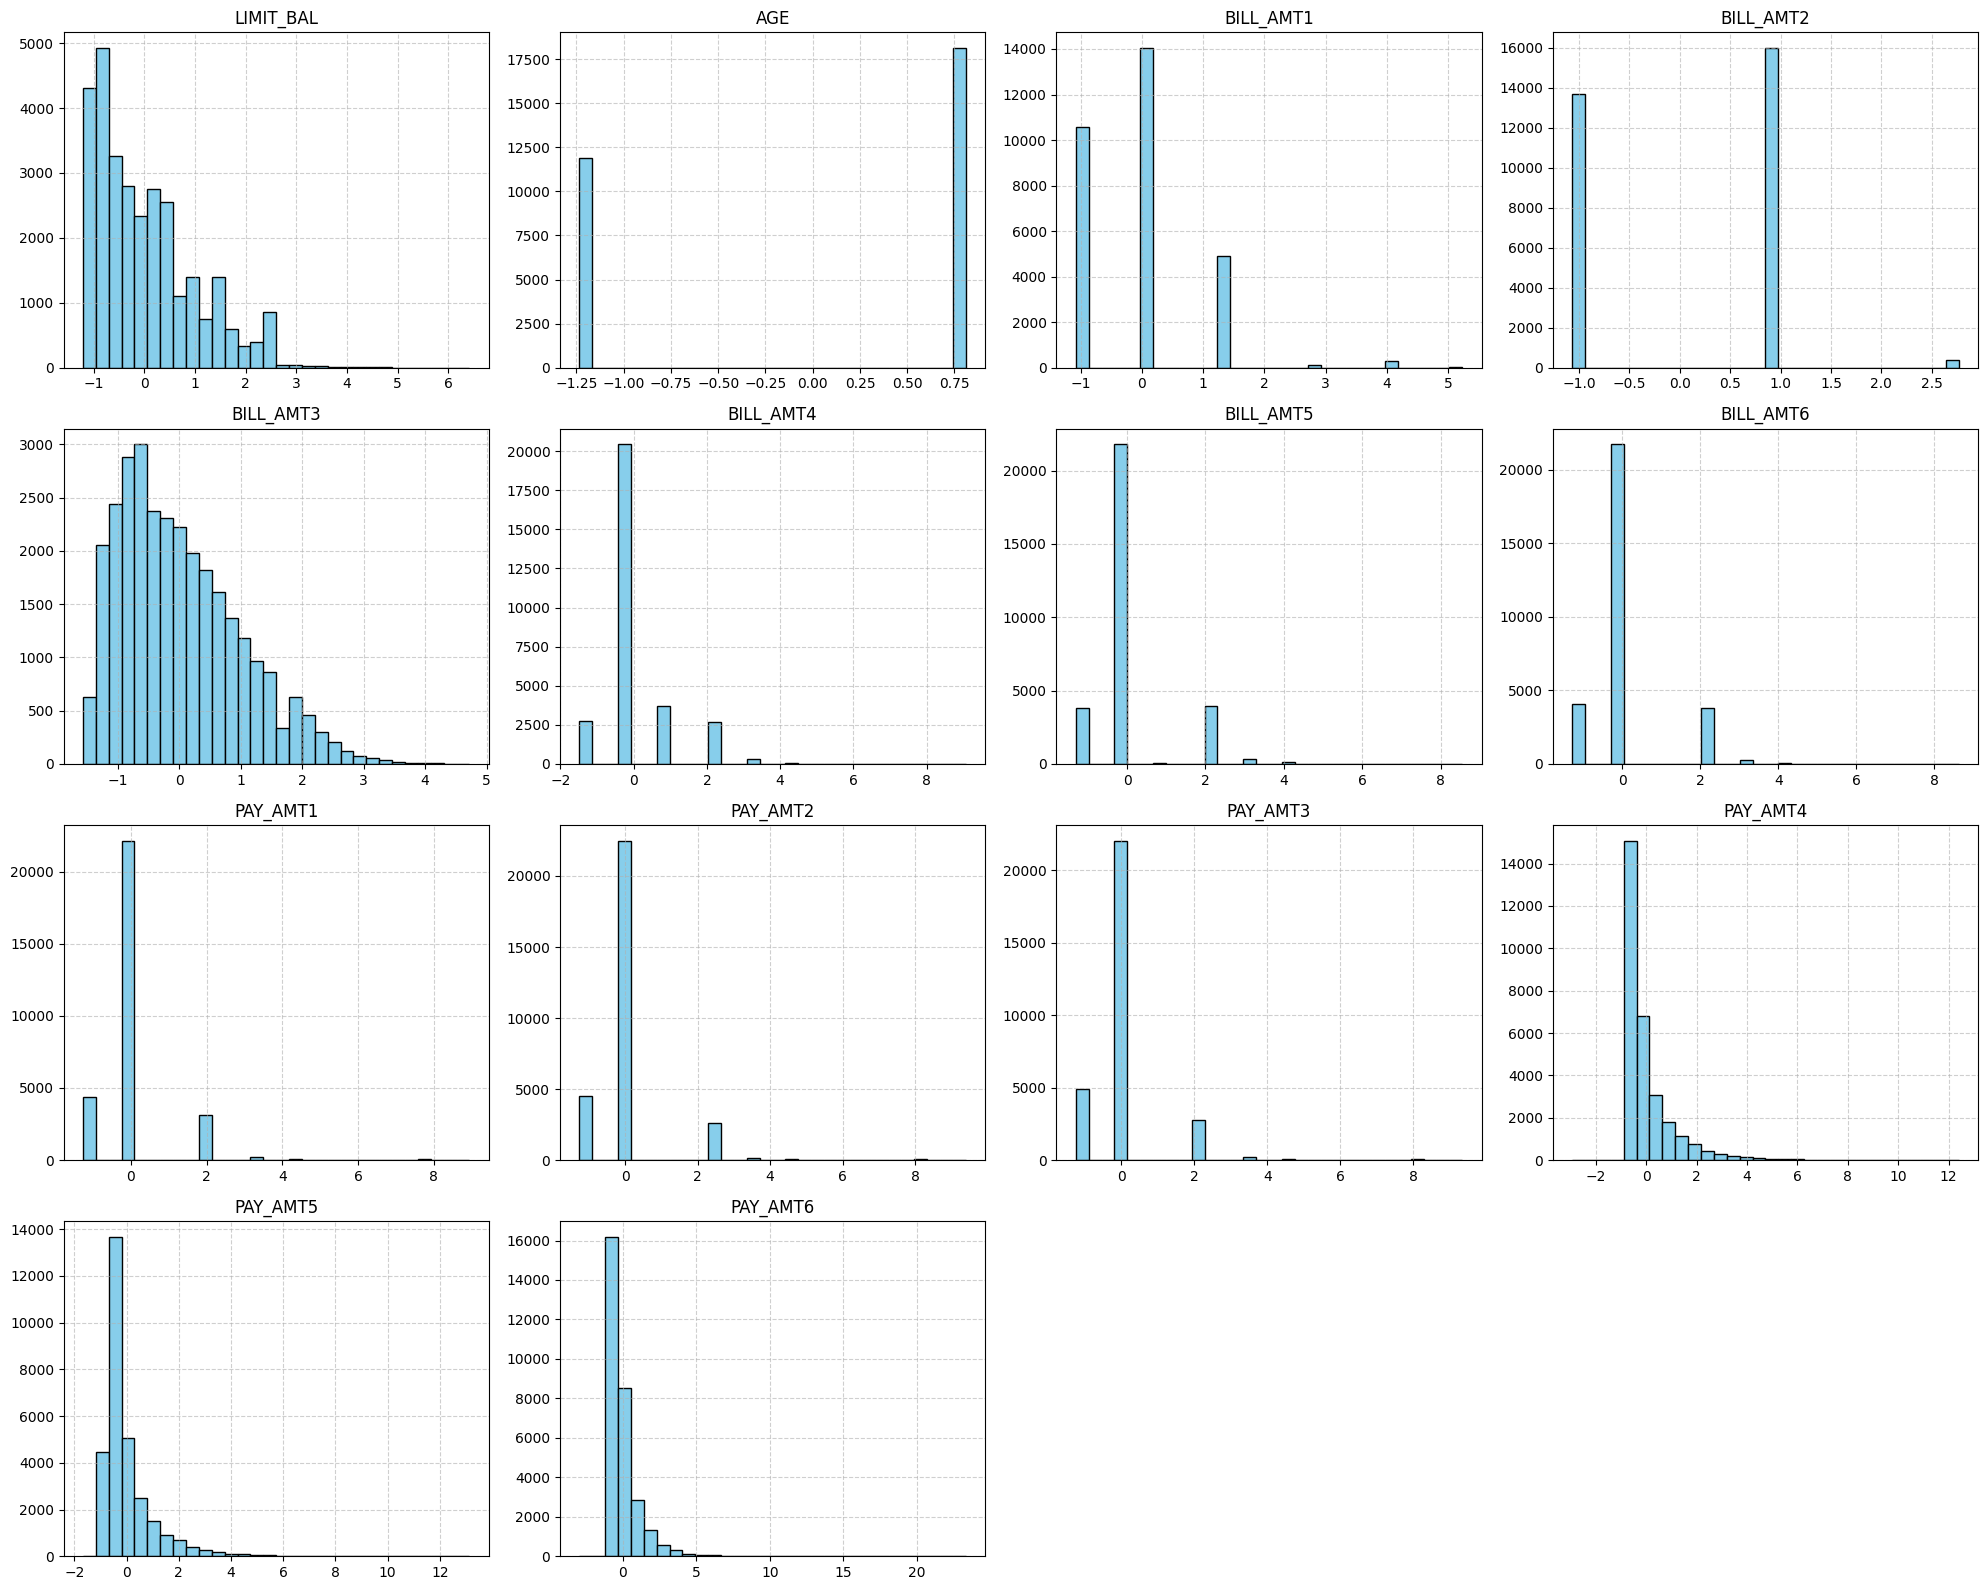

In [12]:
# 3. Standardization and normalization

log_after_std_cols = ['LIMIT_BAL', 'AGE'] \
                   + [f'BILL_AMT{i}' for i in range(1, 7)] \
                   + [f'PAY_AMT{i}' for i in range(1, 7)] \


col_indices = [X.columns.get_loc(col) for col in log_after_std_cols]

# Custom shifted log1p transformer
class ShiftedLogTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.min_ = np.min(X, axis=0)
        return self
    def transform(self, X):
        shifted = X - self.min_ + 1e-5
        return np.log1p(shifted)


# Create pipeline
pipeline = Pipeline([
    ('standardize', StandardScaler()),
])

X_transformed = pipeline.fit_transform(X)

# ColumnTransformer reorders columns: transformed first, then passthrough
transformed_cols = [X.columns[i] for i in col_indices]
passthrough_cols = [col for col in X.columns if col not in transformed_cols]
final_cols = transformed_cols + passthrough_cols

X_transformed_df = pd.DataFrame(X_transformed, columns=final_cols, index=X.index)


plot_all_histograms(X_transformed_df, bins=30, columns_per_row=4)


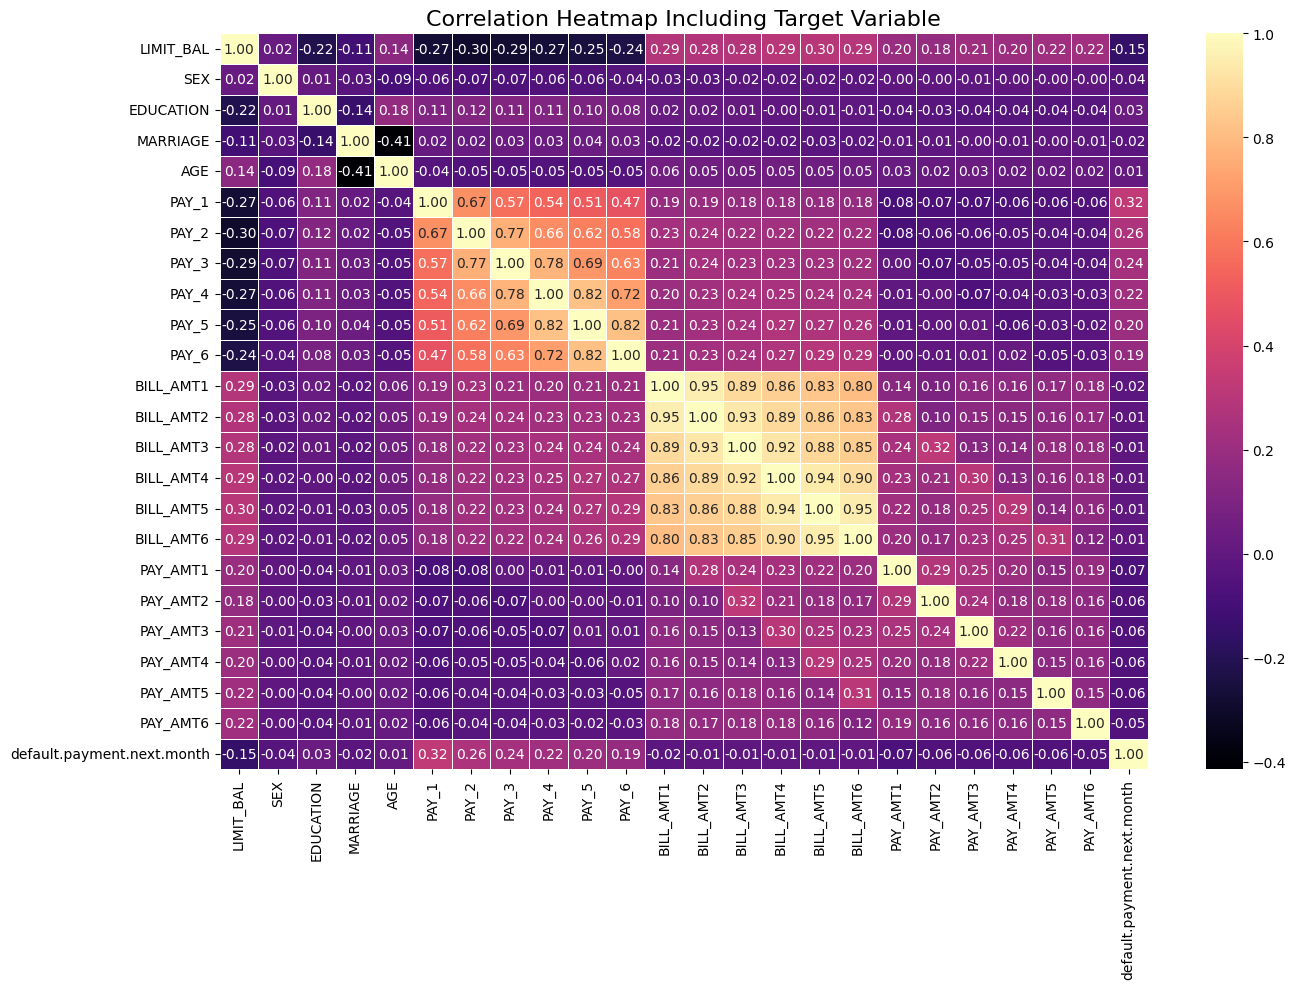

In [13]:
plt.figure(figsize=(14, 10))
sns.heatmap(Xy.corr(), annot=True, cmap='magma', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap Including Target Variable", fontsize=16)
plt.tight_layout()
plt.show()

- The correlation matrix indicates that the input features are not highly correlated with the output variable

- There is a notable correlation between the PAY_I and BILL_AMT_I features

Change the encoding for categorical features: marriage, education, sex, pay_i to one hot encoding

In [14]:
# Apply one-hot encoding
#X_encoded = pd.get_dummies(X, columns=['MARRIAGE', 'EDUCATION', 'SEX', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6'])
X_encoded = pd.get_dummies(X, columns=['MARRIAGE', 'EDUCATION', 'SEX'])
pd.set_option('display.max_columns', None)
print(X_encoded.head())

   LIMIT_BAL  AGE  PAY_1  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6  BILL_AMT1  \
0      20000   24      2      2      0      0     -1     -1       3913   
1     120000   26      0      2      0      0      0      2       2682   
2      90000   34      0      0      0      0      0      0      29239   
3      50000   37      0      0      0      0      0      0      46990   
4      50000   57      0      0      0      0      0      0       8617   

   BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  \
0       3102        689          0          0          0         0       689   
1       1725       2682       3272       3455       3261         0      1000   
2      14027      13559      14331      14948      15549      1518      1500   
3      48233      49291      28314      28959      29547      2000      2019   
4       5670      35835      20940      19146      19131      2000     36681   

   PAY_AMT3  PAY_AMT4  PAY_AMT5  PAY_AMT6  MARRIAGE_1  MARRIAGE_2  MARRIAG

Reduce the features by integrating mean and standard variation on PAY_AMT and BILL_AMT

In [15]:
X_encoded['BILL_AMT_MEAN'] = X_encoded[['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
                                       'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']].mean(axis=1)

X_encoded['BILL_AMT_STD'] = X_encoded[['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
                                      'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']].std(axis=1)

X_encoded['PAY_AMT_MEAN'] = X_encoded[['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
                                       'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']].mean(axis=1)

X_encoded['PAY_AMT_STD'] = X_encoded[['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
                                      'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']].std(axis=1)

Split the dataset

- The performance was lower when i didn't use mean and std on BILL_AMT and PAY_AMT

In [16]:
base_features = ['LIMIT_BAL', 'AGE', 'BILL_AMT_MEAN', 'BILL_AMT_STD',
                 'PAY_AMT_MEAN', 'PAY_AMT_STD',
                 'MARRIAGE_2', 'MARRIAGE_3',
                 'EDUCATION_2', 'EDUCATION_3', 'EDUCATION_4', 'EDUCATION_5', 'EDUCATION_6', 'SEX_1',
                 'SEX_2', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
                #  'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6'

# Get all one-hot encoded PAY_X columns
# pay_encoded_cols = [col for col in X_encoded.columns if any(pay in col for pay in ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6'])]

all_features = base_features #+ pay_encoded_cols

X = X_encoded[all_features]

SMOTEENN applies SMOTE (oversampling) followed by Edited Nearest Neighbors (under-sampling)


## Modeling & Evaluation

- Train various models (including LightGBM and/or CatBoost)
- Use [stratified cross-validation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html)
- Evaluate using various metrics such as accuracy, confussion matrix, ROC-AUC, and basic fairness check (e.g. by gender or age)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from imblearn.combine import SMOTEENN
from collections import defaultdict
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

use_smoteenn = False

def get_models():
    return {
        "logistic_regression": lambda: Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                solver="lbfgs"
            ))
        ]),
        "random_forest": lambda: RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ),
    }

trained_models = defaultdict(list)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

for model_name, model_fn in get_models().items():
    print(f"\n=== Evaluating: {model_name} ===")

    if use_smoteenn:
        smote_enn = SMOTEENN(random_state=42)
        X_resampled, y_resampled = smote_enn.fit_resample(X_train, y_train)
        y_resampled = y_resampled.values.ravel() if hasattr(y_resampled, "values") else y_resampled
    else:
        X_resampled = X_train
        y_resampled = y_train.values.ravel()

    model = model_fn()
    model.fit(X_resampled, y_resampled)

    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    trained_models[model_name].append(model)

    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_pred_proba)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred)

    print(
        f"Accuracy: {acc:.4f}, "
        f"F1: {f1:.4f}, "
        f"Precision: {precision:.4f}, "
        f"Recall: {recall:.4f}, "
        f"ROC AUC: {roc:.4f}"
    )


=== Evaluating: logistic_regression ===
Accuracy: 0.7655, F1: 0.5147, Precision: 0.4746, Recall: 0.5622, ROC AUC: 0.7395

=== Evaluating: random_forest ===
Accuracy: 0.8110, F1: 0.4595, Precision: 0.6252, Recall: 0.3632, ROC AUC: 0.7623
